# Credit Card Customer Segmentation Analysis

## Project Overview

Proyek ini bertujuan untuk menganalisis karakteristik dan perilaku pengguna kartu kredit serta mengidentifikasi kelompok pelanggan berdasarkan pola penggunaan kartu kredit.

Analisis dilakukan menggunakan Python dengan pendekatan Data Analysis dan Data Mining, mulai dari data cleaning, exploratory data analysis (EDA), feature engineering, hingga customer segmentation menggunakan metode K-Means Clustering.

### Objectives
- Memahami karakteristik pengguna kartu kredit.
- Mengidentifikasi pola penggunaan kartu kredit.
- Mengelompokkan customer berdasarkan karakteristik perilakunya.
- Menghasilkan insight yang dapat mendukung strategi customer targeting.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
 df = pd.read_csv('/content/drive/MyDrive/dataset/CC GENERAL.csv')
 df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [ ]:
df.shape

(8950, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['CUST_ID'].duplicated().sum()

np.int64(0)

In [ ]:
df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].describe()

,CREDIT_LIMIT,MINIMUM_PAYMENTS
count,8949.000000,8637.000000
mean,4494.449450,864.206542
std,3638.815725,2372.446607
min,50.000000,0.019163
25%,1600.000000,169.123707
50%,3000.000000,312.343947
75%,6500.000000,825.485459
max,30000.000000,76406.207520


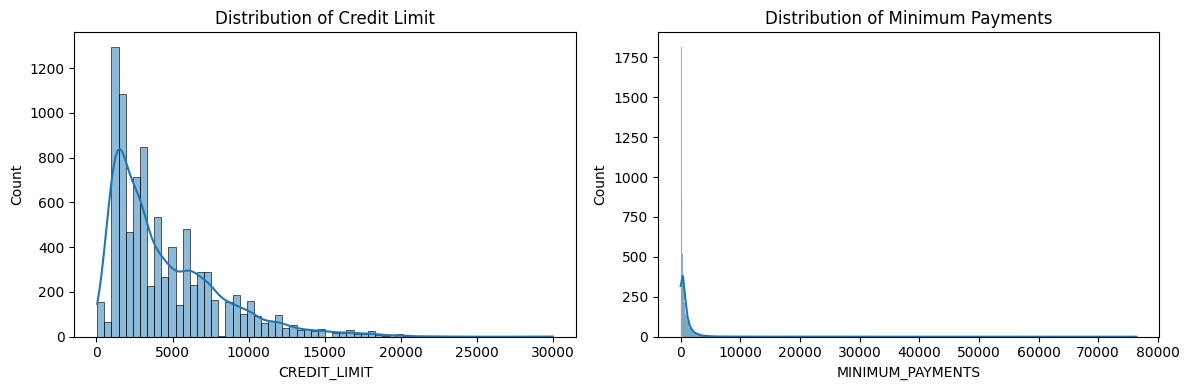

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['CREDIT_LIMIT'], kde=True)
plt.title('Distribution of Credit Limit')

plt.subplot(1, 2, 2)
sns.histplot(df['MINIMUM_PAYMENTS'], kde=True)
plt.title('Distribution of Minimum Payments')

plt.tight_layout()
plt.show()

# **Data Cleaning**



Based on the initial data quality assessment, missing values were identified in two variables:

- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

Since the missing values represent a relatively small proportion of the dataset, the records were retained and missing values were imputed using the median. Median imputation was selected because financial variables may contain extreme values and skewed distributions, making the median more robust than the mean.

In [ ]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(
    df['CREDIT_LIMIT'].median()
)

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(
    df['MINIMUM_PAYMENTS'].median()
)

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].describe()

,CREDIT_LIMIT,MINIMUM_PAYMENTS
count,8950.000000,8950.000000
mean,4494.282473,844.906767
std,3638.646702,2332.792322
min,50.000000,0.019163
25%,1600.000000,170.857654
50%,3000.000000,312.343947
75%,6500.000000,788.713501
max,30000.000000,76406.207520


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df['CUST_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


## Exploratory Data Analysis

This section explores customer behavior related to credit card usage, purchases, cash advances, payments, and credit limits.

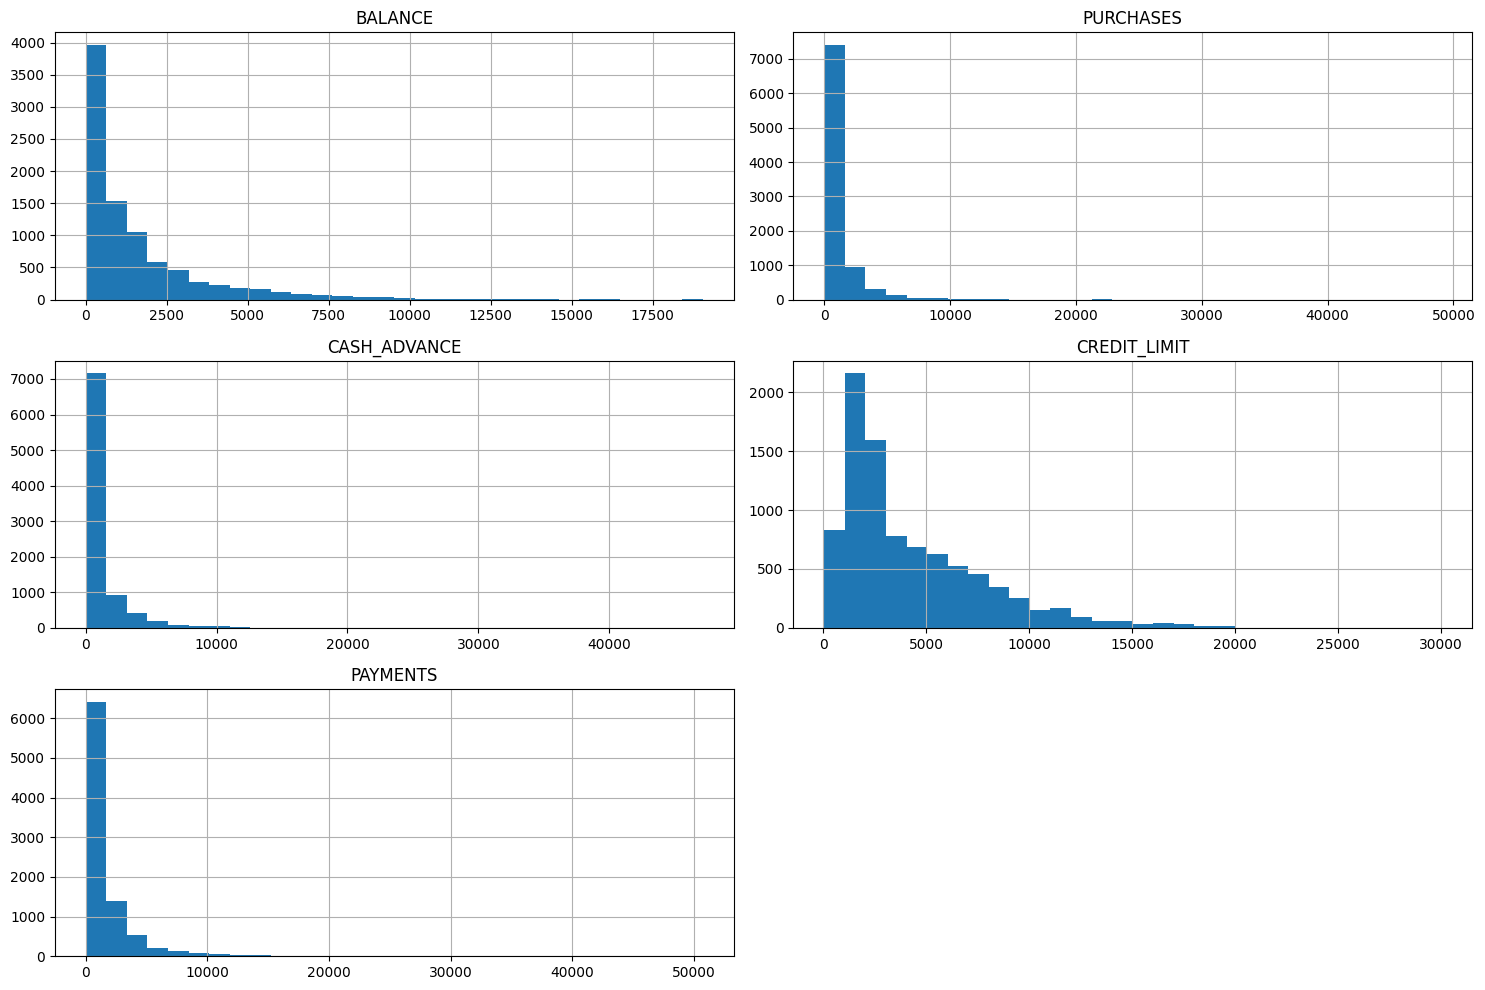

In [ ]:
features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

df[features].hist(figsize=(15, 10), bins=30)

plt.tight_layout()
plt.show()

In [ ]:
df[
    [
        'BALANCE',
        'PURCHASES',
        'CASH_ADVANCE',
        'CREDIT_LIMIT',
        'PAYMENTS'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
PURCHASES,8950.0,1003.204834,2136.634782,0.0,39.635000,361.280000,1110.130000,49039.57000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.0,0.000000,0.000000,1113.821139,47137.21176
CREDIT_LIMIT,8950.0,4494.282473,3638.646702,50.0,1600.000000,3000.000000,6500.000000,30000.00000
PAYMENTS,8950.0,1733.143852,2895.063757,0.0,383.276166,856.901546,1901.134317,50721.48336


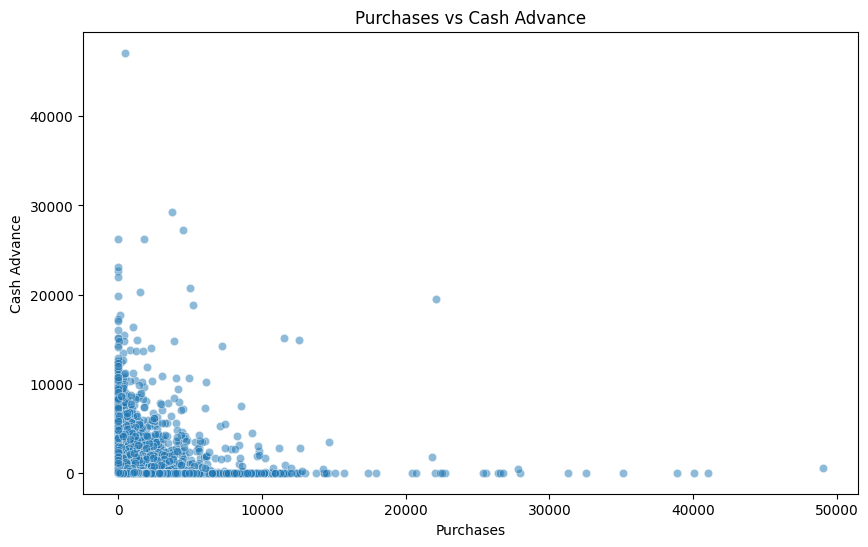

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PURCHASES',
    y='CASH_ADVANCE',
    alpha=0.5
)

plt.title('Purchases vs Cash Advance')
plt.xlabel('Purchases')
plt.ylabel('Cash Advance')

plt.show()

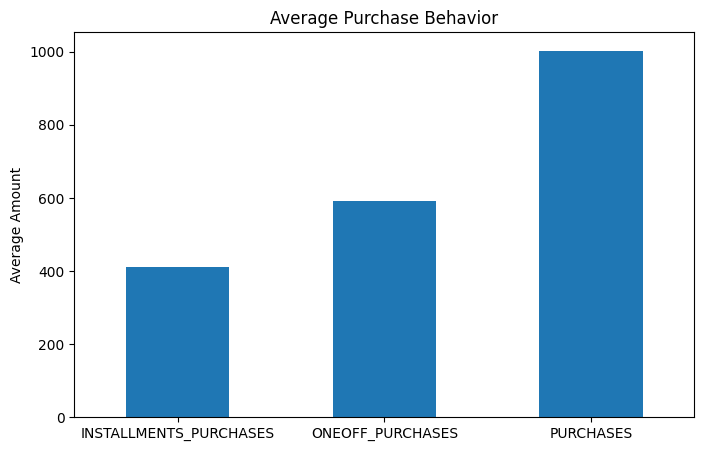

In [ ]:
purchase_features = [
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES'
]

df[purchase_features].mean().sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Purchase Behavior')
plt.ylabel('Average Amount')

plt.xticks(rotation=0)

plt.show()

##Feature Engineering

Additional features were created to provide a clearer representation of customer behavior and financial activity.

In [ ]:
# Create additional behavioral features

df['TOTAL_PURCHASE_ACTIVITY'] = (
    df['ONEOFF_PURCHASES'] +
    df['INSTALLMENTS_PURCHASES']
)

df['TOTAL_TRANSACTION'] = (
    df['PURCHASES_TRX'] +
    df['CASH_ADVANCE_TRX']
)

df['PURCHASE_TO_LIMIT_RATIO'] = (
    df['PURCHASES'] /
    df['CREDIT_LIMIT']
)

df['PAYMENT_TO_BALANCE_RATIO'] = (
    df['PAYMENTS'] /
    (df['BALANCE'] + 1)
)

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_PURCHASE_ACTIVITY,TOTAL_TRANSACTION,PURCHASE_TO_LIMIT_RATIO,PAYMENT_TO_BALANCE_RATIO
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,...,2,1000.0,201.802084,139.509787,0.000000,12,95.40,2,0.095400,4.816193
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,...,0,7000.0,4103.032597,1072.340217,0.222222,12,0.00,4,0.000000,1.280810
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,...,12,7500.0,622.066742,627.284787,0.000000,12,773.17,12,0.103089,0.249211
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,...,1,7500.0,0.000000,312.343947,0.000000,12,1499.00,2,0.199867,0.000000
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,...,1,1200.0,678.334763,244.791237,0.000000,12,16.00,1,0.013333,0.828537


In [ ]:
cluster_features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'PURCHASES_TRX',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

X = df[cluster_features]

X.head()

,BALANCE,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,95.40,0.000000,0.166667,0.000000,2,0,1000.0,201.802084,0.000000,12
1,3202.467416,0.00,6442.945483,0.000000,0.250000,0,4,7000.0,4103.032597,0.222222,12
2,2495.148862,773.17,0.000000,1.000000,0.000000,12,0,7500.0,622.066742,0.000000,12
3,1666.670542,1499.00,205.788017,0.083333,0.083333,1,1,7500.0,0.000000,0.000000,12
4,817.714335,16.00,0.000000,0.083333,0.000000,1,0,1200.0,678.334763,0.000000,12


In [ ]:
X.shape

(8950, 11)

##Data Preprocessing

Feature scaling was applied using StandardScaler because K-Means clustering is sensitive to differences in variable scales.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.73198937, -0.42489974, -0.46678555, ..., -0.52897879,
        -0.52555097,  0.36067954],
       [ 0.78696085, -0.46955188,  2.60560451, ...,  0.81864213,
         0.2342269 ,  0.36067954],
       [ 0.44713513, -0.10766823, -0.46678555, ..., -0.38380474,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.40196519, -0.46678555, ..., -0.5706145 ,
         0.32919999, -4.12276757],
       [-0.74517423, -0.46955188, -0.4493521 , ..., -0.58053567,
         0.32919999, -4.12276757],
       [-0.57257511,  0.04214581, -0.40620512, ..., -0.57686873,
        -0.52555097, -4.12276757]])

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

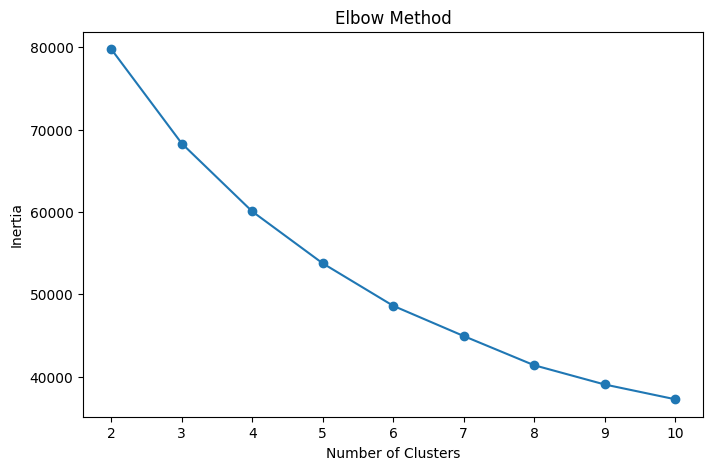

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.xticks(K)

plt.show()

In [ ]:
silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

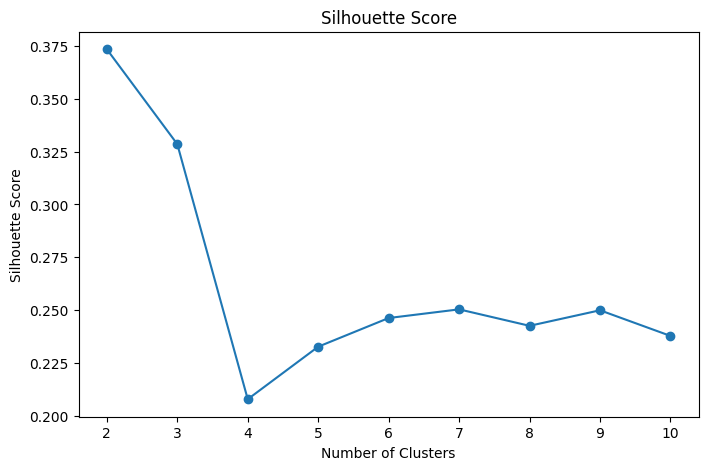

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K, silhouette_scores, marker='o')

plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.xticks(K)

plt.show()

In [ ]:
optimal_k = 4

In [ ]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['CLUSTER'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['CLUSTER'].value_counts().sort_index()

,count
CLUSTER,
0,1184
1,3860
2,413
3,3493


In [ ]:
cluster_profile = df.groupby('CLUSTER')[
    [
        'BALANCE',
        'PURCHASES',
        'CASH_ADVANCE',
        'PURCHASES_FREQUENCY',
        'PURCHASES_TRX',
        'CREDIT_LIMIT',
        'PAYMENTS',
        'PRC_FULL_PAYMENT'
    ]
].mean()

cluster_profile.round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
CLUSTER,,,,,,,,
0,4539.98,566.34,4608.16,0.31,8.53,7641.68,3639.97,0.04
1,1165.52,264.97,660.31,0.17,3.00,3164.60,920.37,0.03
2,3703.13,7404.55,663.03,0.94,90.15,9935.84,7421.17,0.26
3,743.89,1210.21,138.05,0.85,20.82,4253.43,1312.43,0.32


In [ ]:
cluster_size = df['CLUSTER'].value_counts().sort_index()

cluster_size

,count
CLUSTER,
0,1184
1,3860
2,413
3,3493


**VISUALISASI CLUSTER DENGAN PCA**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1', 'PCA2']
)

pca_df['CLUSTER'] = df['CLUSTER']

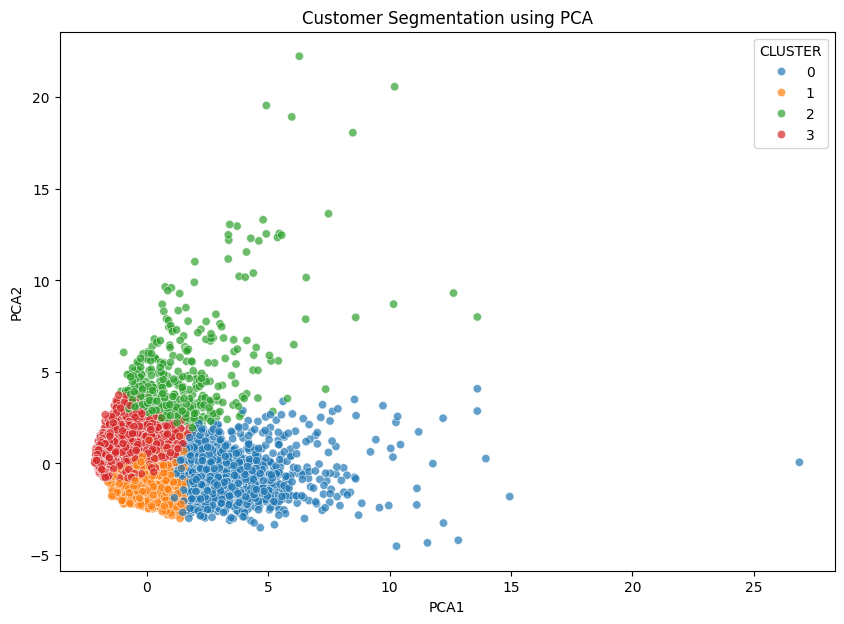

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='CLUSTER',
    palette='tab10',
    alpha=0.7
)

plt.title('Customer Segmentation using PCA')

plt.show()

VISUALISASI KARAKTERISTIK CLUSTER

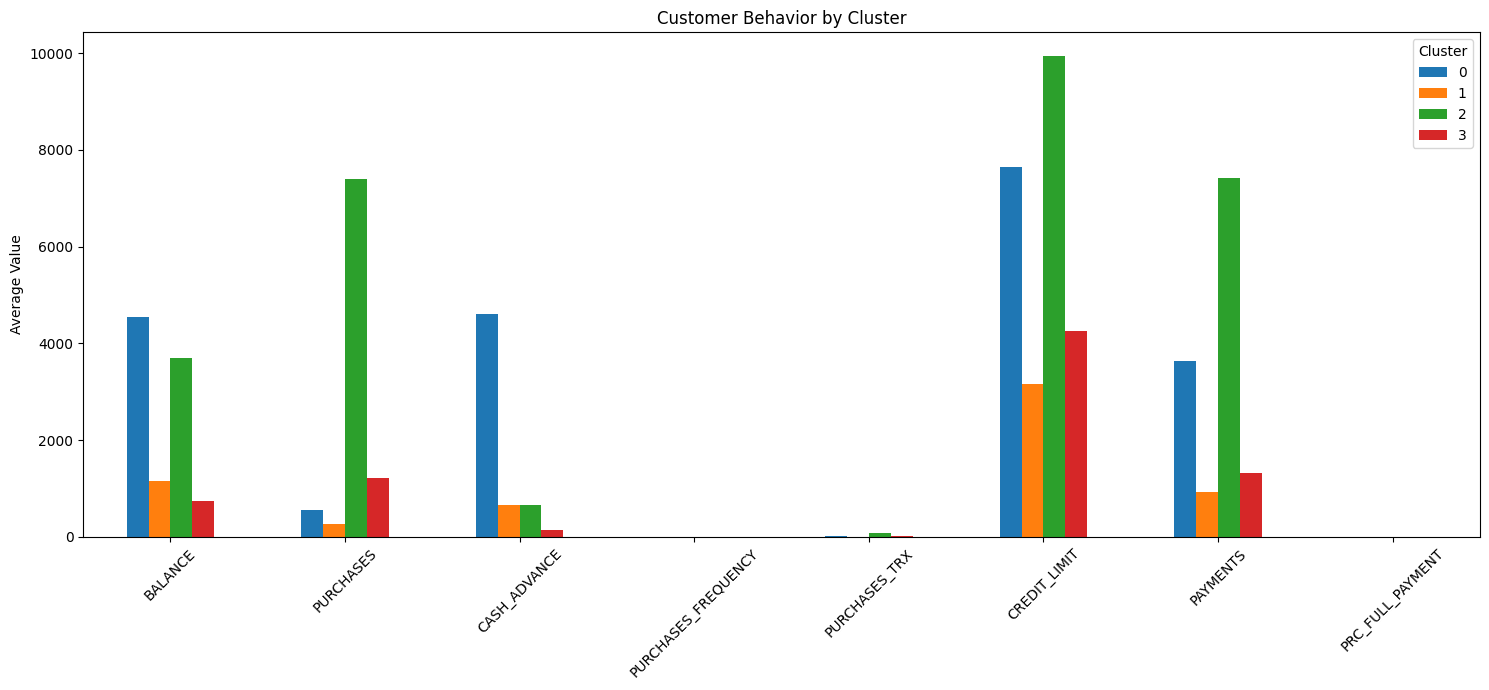

In [ ]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(15, 7)
)

plt.title('Customer Behavior by Cluster')

plt.ylabel('Average Value')

plt.xticks(rotation=45)

plt.legend(title='Cluster')

plt.tight_layout()

plt.show()

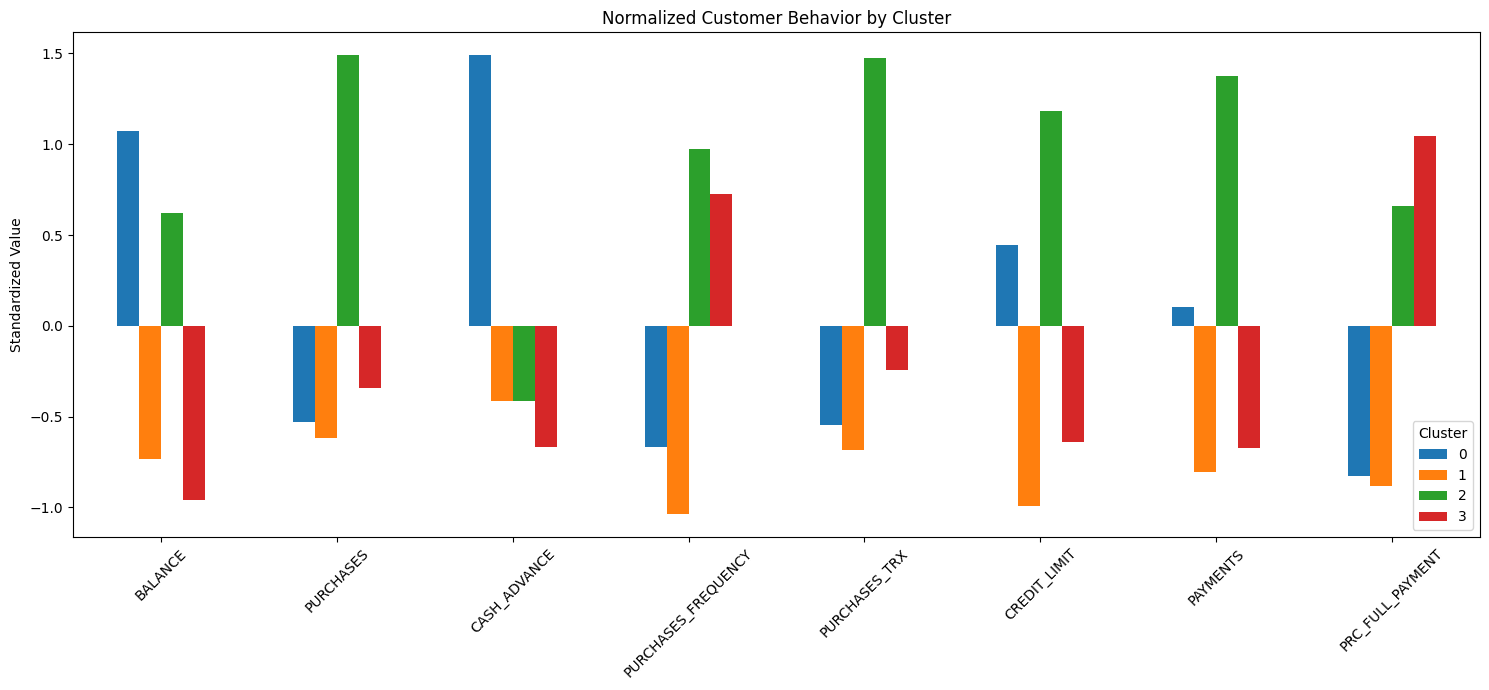

In [ ]:
cluster_profile_normalized = (
    cluster_profile -
    cluster_profile.mean()
) / cluster_profile.std()

cluster_profile_normalized.T.plot(
    kind='bar',
    figsize=(15, 7)
)

plt.title('Normalized Customer Behavior by Cluster')

plt.ylabel('Standardized Value')

plt.xticks(rotation=45)

plt.legend(title='Cluster')

plt.tight_layout()

plt.show()

In [ ]:
cluster_names = {
    0: 'Cash Advance Dependent',
    1: 'Low Engagement',
    2: 'High-Value Active',
    3: 'Frequent Responsible'
}

df['CUSTOMER_SEGMENT'] = df['CLUSTER'].map(cluster_names)

df[['CUST_ID', 'CLUSTER', 'CUSTOMER_SEGMENT']].head()

,CUST_ID,CLUSTER,CUSTOMER_SEGMENT
0,C10001,1,Low Engagement
1,C10002,0,Cash Advance Dependent
2,C10003,3,Frequent Responsible
3,C10004,1,Low Engagement
4,C10005,1,Low Engagement


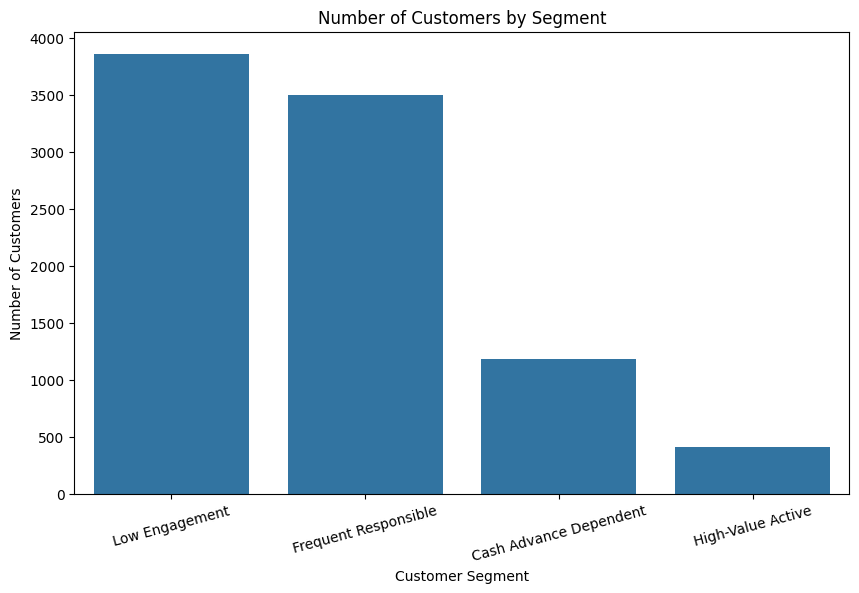

In [ ]:
segment_counts = (
    df['CUSTOMER_SEGMENT']
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.show()

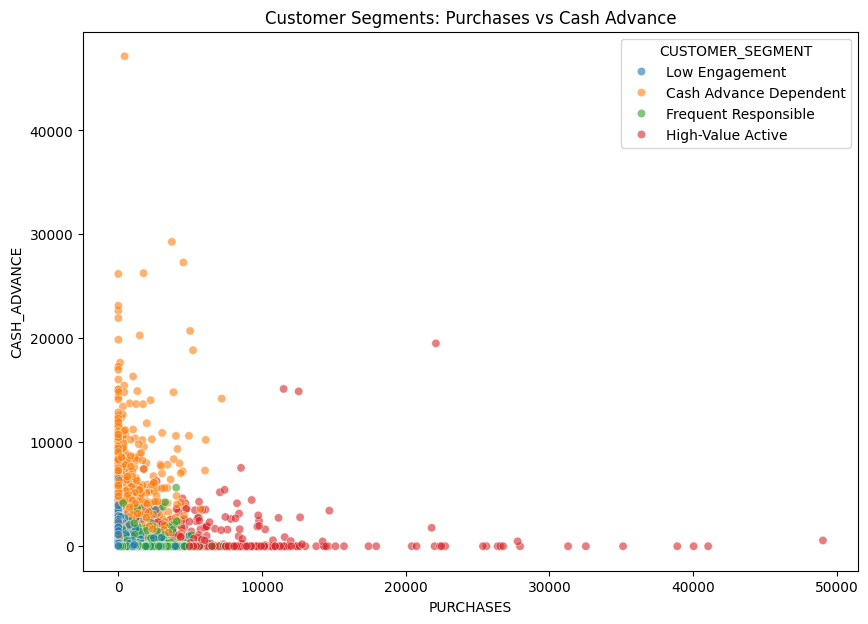

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='PURCHASES',
    y='CASH_ADVANCE',
    hue='CUSTOMER_SEGMENT',
    alpha=0.6
)

plt.title('Customer Segments: Purchases vs Cash Advance')

plt.show()

# **Customer Segment Insights**

The K-Means clustering analysis identified four distinct customer segments based on credit card usage behavior.

### 1. Cash Advance Dependent Customers
Customers in this segment have high account balances and the highest cash advance activity, while their purchase activity is relatively low.

### 2. Low Engagement Customers
This is the largest customer segment and is characterized by low purchase activity, low transaction frequency, and relatively low payment amounts.

### 3. High-Value Active Customers
This segment represents the smallest group but demonstrates the highest purchase value, purchase frequency, transaction activity, and payment amounts.

### 4. Frequent Responsible Customers
Customers in this segment frequently use their credit cards for purchases, maintain relatively low balances, have low cash advance activity, and demonstrate the highest full payment behavior among the identified segments.